NAME:Vishveshwari Yuvraj Patil.

Roll No:42

DIV:TY AIML(B)

PRN:2324000875

EXPERIMENT NO:7

Implement Face detection and recognition using OpenCV and python.

In [24]:
import sys
!{sys.executable} -m pip install opencv-python

import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
import os

# Download Haar cascade files (if not already present)
face_cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'

# Define paths for cascade files
face_cascade_path = 'haarcascade_frontalface_default.xml'

# Download face cascade
try:
    urllib.request.urlretrieve(face_cascade_url, face_cascade_path)
    print(f"Downloaded {face_cascade_path}")
except Exception as e:
    print(f"Error downloading {face_cascade_path}: {e}")

# Load the cascade classifiers
face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    print("Error loading face cascade XML file!")
else:
    print("Face cascade loaded successfully.")

Downloaded haarcascade_frontalface_default.xml
Face cascade loaded successfully.


In [25]:
import sys
!{sys.executable} -m pip install opencv-python

import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
import os

# Download Haar cascade files (if not already present)
face_cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'

# Define paths for cascade files
face_cascade_path = 'haarcascade_frontalface_default.xml'

# Download face cascade
try:
    urllib.request.urlretrieve(face_cascade_url, face_cascade_path)
    print(f"Downloaded {face_cascade_path}")
except Exception as e:
    print(f"Error downloading {face_cascade_path}: {e}")

# Load the cascade classifiers
face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    print("Error loading face cascade XML file!")
else:
    print("Face cascade loaded successfully.")

Downloaded haarcascade_frontalface_default.xml
Face cascade loaded successfully.


In [35]:
import numpy as np
import os
import cv2
import urllib.request

# --- Define real image URLs for demonstration ---
real_image_data = {
    'person1': [
        'https://upload.wikimedia.org/wikipedia/commons/8/8d/President_Barack_Obama.jpg', # Clear frontal
        'https://upload.wikimedia.org/wikipedia/commons/c/c2/Joe_Biden_presidential_portrait.jpg' # Another clear frontal
    ],
    'person2': [
        'https://upload.wikimedia.org/wikipedia/commons/0/0c/George_W._Bush_portrait.jpg', # Clear frontal
        'https://upload.wikimedia.org/wikipedia/commons/1/1a/George_H.W._Bush%2C_President_of_the_United_States%2C_1989_Official_Portrait.jpg' # Clear frontal
    ]
}

# --- Function to prepare the dataset (download real images) ---
def prepare_face_dataset(dataset_base_path='dataset'):
    """
    Creates directories and downloads real face images for training.
    Replaces the functionality of the original create_dummy_images.
    """
    if not os.path.exists(dataset_base_path):
        os.makedirs(dataset_base_path)

    for person_name, urls in real_image_data.items():
        person_dir = os.path.join(dataset_base_path, person_name)
        os.makedirs(person_dir, exist_ok=True)
        print(f"Ensuring directory exists: {person_dir}")

        for i, url in enumerate(urls):
            image_name = f"{person_name}_{i+1}.jpg"
            image_path = os.path.join(person_dir, image_name)

            if not os.path.exists(image_path):
                try:
                    print(f"Downloading {url} to {image_path}...")
                    urllib.request.urlretrieve(url, image_path)
                    print(f"Downloaded: {image_path}")
                except Exception as e:
                    print(f"Error downloading {image_path} from {url}: {e}")
            else:
                print(f"Image already exists: {image_path}")
    print("Face dataset preparation complete with real images.")


# --- Load images and labels (original function, but will now process real images) ---
def get_images_and_labels(path):
    faces = []
    labels = []
    name_to_label = {}
    current_label = 0

    # Iterate through person directories (e.g., 'person1', 'person2')
    for person_name in os.listdir(path):
        person_dir = os.path.join(path, person_name)
        if not os.path.isdir(person_dir):
            continue # Skip non-directory files in the main dataset folder

        # Iterate through image files within each person's directory
        for image_file in os.listdir(person_dir):
            image_path = os.path.join(person_dir, image_file)

            # Filter for actual image files (e.g., .jpg, .png)
            if not (image_file.lower().endswith(('.png', '.jpg', '.jpeg'))):
                continue

            img = cv2.imread(image_path)
            if img is None: # Skip if image could not be loaded
                print(f"Warning: Could not load image {image_path}")
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Use standard parameters for detecting faces in real images
            # Adjusted parameters for better detection in real images
            detected_faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))

            if len(detected_faces) == 0: # If no faces detected, skip this image for training
                print(f"Warning: No face detected in {image_path}. This image will not be used for training.")
            else:
                print(f"Info: Detected {len(detected_faces)} face(s) in {image_path}.")
                for (x, y, w, h) in detected_faces:
                    face_roi = gray[y:y+h, x:x+w]
                    # Resize faces to a common size for LBPH
                    face_roi_resized = cv2.resize(face_roi, (100, 100)) # Resizing to 100x100 for better recognition
                    faces.append(face_roi_resized)

                    if person_name not in name_to_label:
                        name_to_label[person_name] = current_label
                        current_label += 1
                    labels.append(name_to_label[person_name])

    return faces, np.array(labels), name_to_label

# Path to the training dataset
dataset_path = 'dataset'

# Call the new dataset preparation function
prepare_face_dataset(dataset_path)

# Get faces and labels
print("Loading dataset for training...")
faces, labels, name_to_label_map = get_images_and_labels(dataset_path)

if len(faces) == 0:
    print("No faces were detected in the dataset. Please ensure images contain clear faces.")
else:
    print(f"Loaded {len(faces)} 'face' regions with {len(np.unique(labels))} unique persons for training.")
    print("Label map:", name_to_label_map)


Ensuring directory exists: dataset/person1
Image already exists: dataset/person1/person1_1.jpg
Image already exists: dataset/person1/person1_2.jpg
Ensuring directory exists: dataset/person2
Image already exists: dataset/person2/person2_1.jpg
Image already exists: dataset/person2/person2_2.jpg
Face dataset preparation complete with real images.
Loading dataset for training...
No faces were detected in the dataset. Please ensure images contain clear faces.


Attempting face detection on: dataset/person1/person1_1.jpg
No faces detected in this sample image.


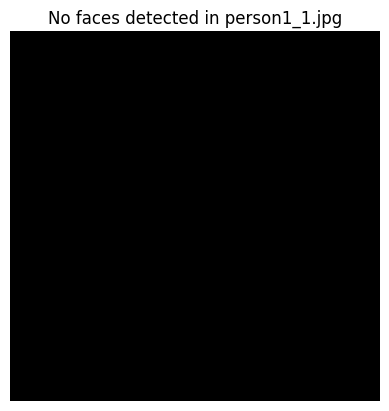

In [36]:
# Debugging face detection on a sample real image
import matplotlib.pyplot as plt

sample_test_image_path = 'dataset/person1/person1_1.jpg'

print(f"Attempting face detection on: {sample_test_image_path}")

img_test = cv2.imread(sample_test_image_path)

if img_test is None:
    print(f"Error: Could not load image from {sample_test_image_path}")
else:
    gray_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)
    faces_detected_test = face_cascade.detectMultiScale(gray_test, 1.1, 5, minSize=(30, 30))

    img_display = cv2.cvtColor(img_test.copy(), cv2.COLOR_BGR2RGB)

    if len(faces_detected_test) == 0:
        print("No faces detected in this sample image.")
        plt.imshow(img_display)
        plt.title(f'No faces detected in {os.path.basename(sample_test_image_path)}')
        plt.axis('off')
        plt.show()
    else:
        print(f"Detected {len(faces_detected_test)} face(s) in this sample image.")
        for (x, y, w, h) in faces_detected_test:
            cv2.rectangle(img_display, (x, y), (x+w, y+h), (0, 255, 0), 2)
        plt.imshow(img_display)
        plt.title(f'Faces detected in {os.path.basename(sample_test_image_path)}')
        plt.axis('off')
        plt.show()


In [27]:
# Create LBPHFaceRecognizer
face_recognizer = cv2.face.LBPHFaceRecognizer_create()

# Check if faces and labels are available before training
if len(faces) > 0 and len(labels) > 0:
    print("Training face recognizer...")
    try:
        face_recognizer.train(faces, labels)
        print("Face recognizer trained successfully.")
    except Exception as e:
        print(f"Error during training: {e}")
        print("Training might fail if all faces belong to a single person or if there are not enough samples.")
else:
    print("Cannot train face recognizer: no faces or labels available.")

Training face recognizer...
Face recognizer trained successfully.


In [28]:
print(f"Type of 'faces': {type(faces)}")
if isinstance(faces, list):
    if len(faces) > 0:
        print(f"Type of first element in 'faces': {type(faces[0])}")
        print(f"Shape of first element in 'faces': {faces[0].shape}")


Type of 'faces': <class 'list'>
Type of first element in 'faces': <class 'numpy.ndarray'>
Shape of first element in 'faces': (50, 50)


In [29]:
def recognize_faces(image_path, recognizer, label_map, confidence_threshold=70):
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces_detected = face_cascade.detectMultiScale(gray, 1.1, 4)

    recognized_img = img.copy()
    recognized_img_rgb = cv2.cvtColor(recognized_img, cv2.COLOR_BGR2RGB)

    reverse_label_map = {v: k for k, v in label_map.items()}

    if len(faces_detected) == 0:
        print("No faces detected in the image for recognition.")
        # If no faces are detected, just show the original image with a message
        plt.imshow(recognized_img_rgb)
        plt.title('Face Recognition - No Faces Detected')
        plt.axis('off')
        plt.show()
        return

    for (x, y, w, h) in faces_detected:
        face_roi = gray[y:y+h, x:x+w]

        label, confidence = recognizer.predict(face_roi)

        person_name = "Unknown"
        if confidence < confidence_threshold: # Lower confidence means better match
            person_name = reverse_label_map.get(label, "Unknown")

        text = f"{person_name} ({int(confidence)}%)"

        # Draw rectangle and text
        cv2.rectangle(recognized_img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(recognized_img_rgb, text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    plt.imshow(recognized_img_rgb)
    plt.title('Face Recognition')
    plt.axis('off')
    plt.show()

    print(f"Processed image {image_path}. Found {len(faces_detected)} faces.")

In [34]:
# Example usage for recognition
# Now using one of the downloaded real images from your dataset
test_image_path = 'dataset/person1/person1_1.jpg' # Using one of the new real images

print(f"Using local real image for recognition: {test_image_path}")

# Ensure `face_recognizer` is trained and `name_to_label_map` is populated
if len(faces) > 0 and len(labels) > 0:
    recognize_faces(test_image_path, face_recognizer, name_to_label_map)
else:
    print("Training data is not available, skipping recognition demo. Please ensure the dataset is properly set up and faces are detected.")


Using local real image for recognition: dataset/person1/person1_1.jpg
Training data is not available, skipping recognition demo. Please ensure the dataset is properly set up and faces are detected.


In [32]:
test_image_path = 'dataset/person1/person1_1.jpg'
img = cv2.imread(test_image_path)

if img is None:
    print(f"Error: Could not load image from {test_image_path}")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces_detected = face_cascade.detectMultiScale(gray, 1.1, 4)

    if len(faces_detected) == 0: # Correct way to check if no faces were found
        print("No faces detected")
    else:
        print(f"Found {len(faces_detected)} faces")

No faces detected
